# **NOTEBOOK 04 - Anomalies & Early Warning Signals**
---

**Goal:** detect signatures of approach to a bifurcation in the AMOC intensity record, using two lenses — *classical* early warning signals (rolling variance, lag-1 autocorrelation) and an *ML* anomaly detector (Isolation Forest) — and compare where they converge and diverge.

**Guiding question:** do the classical EWS show the rising trend that critical-slowing-down theory predicts near a bifurcation (Scheffer et al., 2009), and does an ML anomaly detector flag the same periods? Crucially: *how robust are these signals to the methodological choices (detrending, window length) that the literature shows can fabricate or erase them?*

**Why this matters for the thesis.** This is objective O1.2 (Chapter 6, §6.3). It is the analytical core of Part I and the most methodologically contested: Boers (2021) reports AMOC EWS; Ben-Yami et al. (2023, 2024) challenge them precisely on detrending and window choices. Our stance (per §4.4.3) is not to resolve the debate but to apply the framework honestly, **making every choice explicit and testing the signal's sensitivity to it.**

**Inputs:** `pca_vertical_scores.npz` — `pc1` (the AMOC intensity series PC1(t), 14,596 daily values), produced and persisted in NB03.

**Why PC1(t):** it is the maximum-variance projection of the vertical structure — the cleanest available intensity signal — and physically equivalent to the coherent strengthening/weakening of the overturning, hence comparable to the MOC-index EWS in the literature.

**Non-goals:** the autoencoder (NB05) and forecasting (future work). Here: classical EWS + Isolation Forest only.

**Author:** Enrico Vaccari  
**Date:** 04.06.2026

Loaded PC1(t) from pca_vertical_scores.npz
  length     : 14,596 days
  span       : 2004-04-02 → 2024-03-25
  PC1 var    : 89.8% of vertical variance
  PC1 mean/std: -0.00 / 56.65


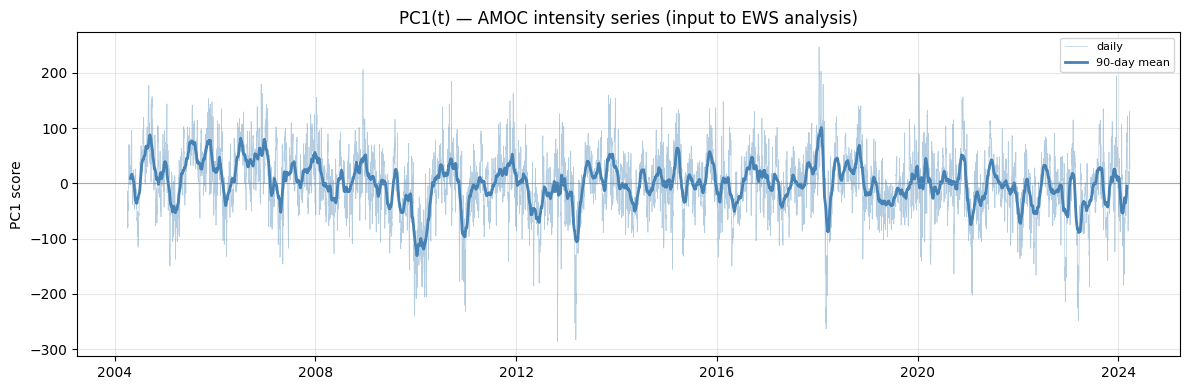

In [1]:
# Standard imports
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_CODE = NOTEBOOK_DIR.parent
if str(PROJECT_CODE) not in sys.path:
    sys.path.insert(0, str(PROJECT_CODE))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

from pipeline.paths import DATA_PROCESSED

# --- Reload the PCA outputs from NB03 (no recomputation) ---
scores_path = DATA_PROCESSED / "pca_vertical_scores.npz"
data = np.load(scores_path)

# Load PC1(t) and PC2(t) — the first two principal components of the vertical profiles, which represent the dominant modes of variability in the AMOC intensity. PC1(t) is our main focus for EWS analysis, while PC2(t) can be used for reference or further exploration.
pc1 = data['pc1']                              # AMOC intensity series, other PCs are available (PC2, PC3) but we focus on PC1 for EWS analysis
pc2 = data['pc2']                              # PC2(t) is the second mode of variability, which we won't analyze here but is available for reference

# Load the aligned daily timestamps and the variance explained by each PC. 
times = pd.to_datetime(data['times'])          # aligned daily axis
var_explained = data['var_explained']

print(f"Loaded PC1(t) from {scores_path.name}")
print(f"  length     : {len(pc1):,} days")
print(f"  span       : {times[0].date()} → {times[-1].date()}")
print(f"  PC1 var    : {var_explained[0]*100:.1f}% of vertical variance")
print(f"  PC1 mean/std: {pc1.mean():+.2f} / {pc1.std():.2f}")

# Build a pandas Series — convenient for rolling statistics and date handling
pc1_series = pd.Series(pc1, index=times, name='PC1_intensity')

# Quick look at the raw series before any EWS analysis
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(pc1_series.index, pc1_series.values, color='steelblue',
        alpha=0.4, linewidth=0.5, label='daily')
ax.plot(pc1_series.index, pc1_series.rolling(90, center=True).mean(),
        color='steelblue', linewidth=2, label='90-day mean')
ax.axhline(0, color='gray', linewidth=0.8, alpha=0.6)
ax.set_title('PC1(t) — AMOC intensity series (input to EWS analysis)')
ax.set_ylabel('PC1 score')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

**Reading the input series, and what it dictates for the method.**

PC1(t) is **essentially flat around zero** across the twenty-year record: the 90-day mean oscillates around zero with no systematic slope. PC1 is centered by construction (PCA subtracts the mean), so it cannot carry an offset — but it *could* have carried a trend (a progressive decline, say), and it does not show one clearly. Twenty years is too short for a multidecadal trend to emerge above interannual variability, exactly as Ch.5 §5.2 anticipates.

Two features that *are* present, and that matter for the EWS:

> - **2009–2010 is the deepest negative excursion of the whole record** — the dip to roughly −120/−150 in the 90-day mean. The same event identified in NB01 and NB03, here at its absolute minimum.
> - **Variability appears to change over time.** The daily envelope looks wider around 2010–2013 (excursions to −280, +180) than, for instance, 2014–2016. This is precisely what rolling variance quantifies — but *"appears"* is not *"is"*, so it will be measured, not asserted.

**Consequence for detrending.** With no strong linear trend, we are in a fortunate position: detrending will be light, which makes the resulting EWS more robust to the critique of Ben-Yami et al. (2023, 2024). We do **not** take this for granted. The correct procedure is still to remove the low-frequency component (a moving mean) before computing variance and AR1, since EWS must be measured on the *fluctuations around the local trend*, not on the raw signal — and then to show the result does not change materially as the detrending window is varied. That sensitivity check is the anti-cherry-picking evidence.

**Method choice — rolling window.** EWS are computed in a window that slides day by day, producing a *series* of variance (and AR1) values rather than a single number, so we can see whether dispersion grows over time. Window length is a real choice: too short (e.g. 30 days) and the statistic is noisy; too long (e.g. 5 years) and all structure is flattened. The EWS literature on short records typically uses **1–2 year** windows as the compromise. We adopt **730 days (2 years)** as the primary window and report robustness at 365 and 1095 days.

> *Note on the variance estimator:* pandas `.rolling().var()` divides by (n−1), the Bessel correction (unbiased sample variance). For windows of hundreds of days the difference from dividing by n is negligible, but it is stated here for transparency.

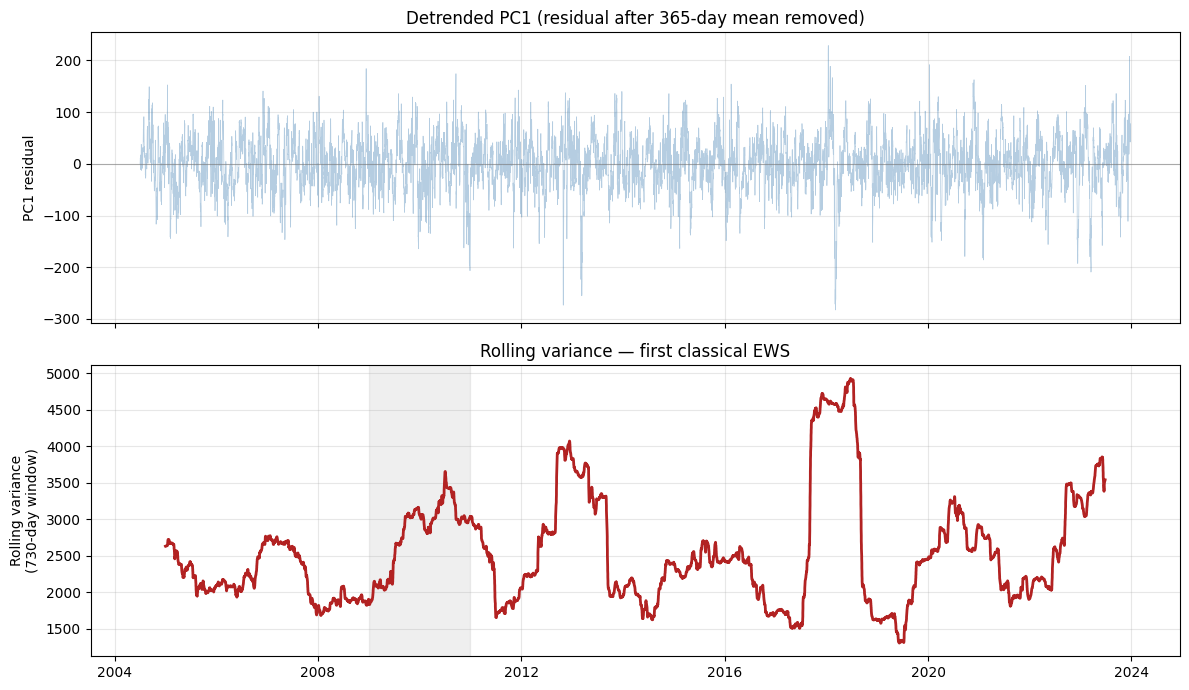

Rolling variance vs time:
  Kendall's tau = +0.078  (p = 2.12e-42)
  tau > 0 → variance rising over record (EWS-consistent)
  tau < 0 → variance falling (against EWS)


In [2]:
# --- Detrend: remove the slow component, keep the fluctuations ---
# Trend = 365-day centered mean. Residual = signal - trend.
# EWS are computed on the residual, not the raw series (Dakos et al., 2012).
detrend_win = 365
trend = pc1_series.rolling(detrend_win, center=True).mean()
residual = pc1_series - trend

# --- Rolling variance on the residual ---
var_win = 730  # 2-year primary window
roll_var = residual.rolling(var_win, center=True).var()  # pandas uses n-1 (Bessel)

# --- Plot: residual + its rolling variance ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(residual.index, residual.values, color='steelblue',
         alpha=0.4, linewidth=0.5)
ax1.axhline(0, color='gray', linewidth=0.8, alpha=0.6)
ax1.set_ylabel('PC1 residual')
ax1.set_title(f'Detrended PC1 (residual after {detrend_win}-day mean removed)')

ax2.plot(roll_var.index, roll_var.values, color='firebrick', linewidth=2)
ax2.set_ylabel(f'Rolling variance\n({var_win}-day window)')
ax2.set_title('Rolling variance — first classical EWS')
# mark the known event
ax2.axvspan(pd.Timestamp('2009-01-01'), pd.Timestamp('2010-12-31'),
            color='gray', alpha=0.12)

plt.tight_layout()
plt.show()

# --- Is there a trend in the variance itself? (the EWS question) ---
# Correlate rolling variance against time (Kendall's tau — robust, standard for EWS)
from scipy.stats import kendalltau
valid = roll_var.dropna()
time_numeric = np.arange(len(valid))
tau, p = kendalltau(time_numeric, valid.values)
print(f"Rolling variance vs time:")
print(f"  Kendall's tau = {tau:+.3f}  (p = {p:.3g})")
print(f"  tau > 0 → variance rising over record (EWS-consistent)")
print(f"  tau < 0 → variance falling (against EWS)")

**Reading the rolling variance: oscillation, not a rising trend.**

Kendall's tau = **+0.078** with a vanishingly small p-value (2×10⁻⁴²). The sign is positive (EWS-consistent direction), but the magnitude is *near zero* on a −1…+1 scale, and **the p-value is misleading and must not be read as strong evidence.**

> **Why the p-value is an artefact (the central methodological point).** Kendall's test assumes independent points. The 730-day rolling variance is computed on **heavily overlapping windows**: consecutive values share 729 of 730 days. There are not 14,000 independent observations — there are perhaps 20–30 (the number of non-overlapping 2-year windows in the record). The microscopic p-value is a symptom of this **pseudo-replication**: the test believes it has thousands of independent trials when it has a handful. This is precisely the mechanism by which spurious EWS are manufactured (cf. Ben-Yami et al., 2023, 2024).

> **Honest reading:** tau ≈ 0.08 means *no appreciable monotonic trend in variance*. The variance **oscillates** — peaks around 2012–2013 and 2017–2018 (~4900), troughs in 2011 and 2019 — rather than ramping toward a threshold. The system breathes; it does not visibly approach a bifurcation over this window.

> **A physical note.** The 2017–2018 variance peak coincides with the positive PC1 rebound seen in NB03 (+10.73). Consistent: a period of strong AMOC oscillation carries both high variance and large excursions in *both* directions. Variance captures turbulence, not direction.

**Why this is the right result.** Had tau been large with this p-value, it would have implied a strong collapse signal — and collapsed under the first question about pseudo-replication. Instead the finding is honest and defensible: over twenty years of PC1, variance shows **no monotonic critical-slowing-down trend**, consistent with the cautious stance of §4.4.3 and with the critics' argument that the observational record is too short for robust EWS. The next cell quantifies this rigorously by estimating the *effective* number of independent points.

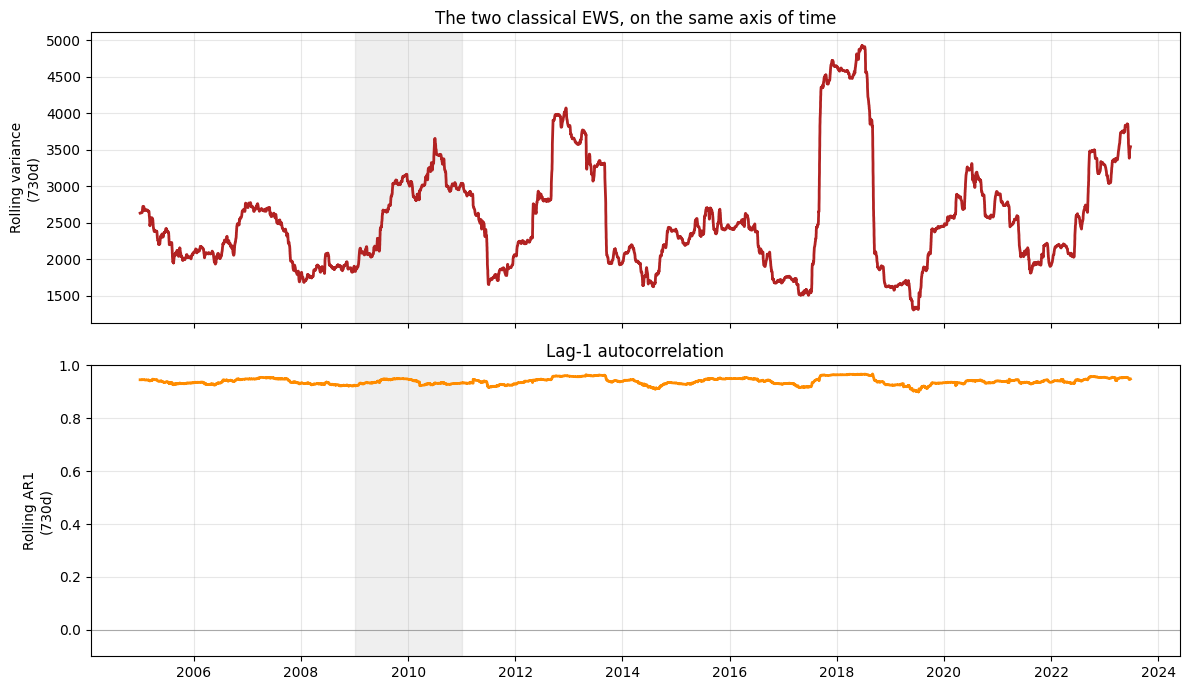

Rolling AR1 vs time (raw, uncorrected):
  Kendall's tau = +0.088  (naive p = 1.27e-52)
  (naive p ignores window overlap — corrected in next cell)


In [3]:
# --- Rolling lag-1 autocorrelation on the same detrended residual ---
# AR1 in a window = Pearson correlation between the residual and itself
# shifted by one day, computed within each 730-day window.
def rolling_ar1(series, window):
    """Lag-1 autocorrelation in a sliding window."""
    def ar1(x):
        x = x[~np.isnan(x)]
        if len(x) < 3:
            return np.nan
        return np.corrcoef(x[:-1], x[1:])[0, 1]
    return series.rolling(window, center=True).apply(ar1, raw=True)

roll_ar1 = rolling_ar1(residual, var_win)   # same 730-day window as variance

# --- Plot variance and AR1 together (the two EWS, read as a pair) ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(roll_var.index, roll_var.values, color='firebrick', linewidth=2)
ax1.set_ylabel(f'Rolling variance\n({var_win}d)')
ax1.set_title('The two classical EWS, on the same axis of time')
ax1.axvspan(pd.Timestamp('2009-01-01'), pd.Timestamp('2010-12-31'),
            color='gray', alpha=0.12)

ax2.plot(roll_ar1.index, roll_ar1.values, color='darkorange', linewidth=2)
ax2.set_ylabel(f'Rolling AR1\n({var_win}d)')
ax2.set_title('Lag-1 autocorrelation')
ax2.set_ylim(-0.1, 1.0)
ax2.axhline(0, color='gray', linewidth=0.8, alpha=0.6)
ax2.axvspan(pd.Timestamp('2009-01-01'), pd.Timestamp('2010-12-31'),
            color='gray', alpha=0.12)

plt.tight_layout()
plt.show()

# Direction of the AR1 trend (raw Kendall, to be corrected next cell)
valid_ar1 = roll_ar1.dropna()
tau_ar1, p_ar1 = kendalltau(np.arange(len(valid_ar1)), valid_ar1.values)
print(f"Rolling AR1 vs time (raw, uncorrected):")
print(f"  Kendall's tau = {tau_ar1:+.3f}  (naive p = {p_ar1:.3g})")
print(f"  (naive p ignores window overlap — corrected in next cell)")

**Reading the two EWS together: concordant null, plus an instructive detail on AR1.**

Rolling AR1 vs time: Kendall's tau = **+0.088** — again near zero, again with a microscopic p-value that is the same pseudo-replication artefact (overlapping windows). The AR1 panel is **nearly flat**: it oscillates in a narrow band with no ascending ramp.

> **Concordance.** Both EWS agree in showing *no monotonic trend* (variance tau ≈ +0.08, AR1 tau ≈ +0.09). Two independent indicators pointing the same way — no detectable approach to a bifurcation over this record — weigh more than either alone. The cautious stance of §4.4.3 is reinforced from two sides.

> **The high AR1 is inertia, not tipping (a key distinction).** AR1 sits at ~0.93–0.96, very close to 1. This is **not** a collapse signal — it is a trivial consequence of the **daily resolution**. The AMOC stream function is a massive, inertial ocean object; one day is a tiny interval relative to its evolution timescales, so today's value almost perfectly resembles yesterday's *by physical construction*. This is background autocorrelation from inertia, not the *rising* autocorrelation that critical slowing down predicts. Conflating the two is exactly the error the critics flag (Ben-Yami et al., 2023, 2024): CSD predicts AR1 that **increases**, not AR1 that is merely high.

> **A methodological consequence (for the limitations chapter).** Because daily AR1 is saturated near 1, it has little headroom to rise even if a trend existed — it is a *poor detector* at this resolution. A more sensitive EWS analysis would use lower-resolution (monthly/seasonal) data, where AR1 has room to move. We note this as a limitation and a direction, not a flaw in the present result.

So:
- variance shows high variability in cycles but no monotonic trend
- AR plot is substantially flat for the entire record --> no growing trend towards 1 which would show a critical progressive slowdown.

In [4]:
from scipy.stats import norm

def lag1_autocorr(x):
    x = x[~np.isnan(x)]
    return np.corrcoef(x[:-1], x[1:])[0, 1]

def kendall_p_corrected(values, n_eff):
    """Kendall tau with p recomputed at N_eff. Guarded against tiny n_eff."""
    tau, _ = kendalltau(np.arange(len(values)), values)
    if n_eff < 4:                       # too few independent points to test
        return tau, np.nan, np.nan
    var_tau = (2 * (2 * n_eff + 5)) / (9 * n_eff * (n_eff - 1))
    z = tau / np.sqrt(var_tau)
    p = 2 * (1 - norm.cdf(abs(z)))
    return tau, p, z

# --- The honest N_eff is set by the PHYSICAL series (PC1 residual),
#     not by the overlap-inflated rolling statistic. ---
res = residual.dropna().values
r_phys = lag1_autocorr(res)
N = len(res)
N_eff_bretherton = N * (1 - r_phys) / (1 + r_phys)

# --- Most transparent estimate: number of NON-overlapping windows ---
n_independent_windows = N / var_win     # record length / window length

print("=" * 64)
print("HOW MANY INDEPENDENT POINTS DO WE ACTUALLY HAVE?")
print("=" * 64)
print(f"\nRaw daily samples           : {N:,}")
print(f"Lag-1 autocorr of PC1 resid : {r_phys:.4f}  (physical inertia)")
print(f"N_eff (Bretherton, on resid): {N_eff_bretherton:.1f}")
print(f"Non-overlapping {var_win}d windows: {n_independent_windows:.1f}")
print(f"\n→ The variance/AR1 trend is being judged on ~{n_independent_windows:.0f} "
      f"independent\n  pieces of information, NOT {N:,}.")

print("\n" + "=" * 64)
print("HONEST SIGNIFICANCE OF EACH EWS TREND")
print("=" * 64)

# Use the non-overlapping window count as the conservative, defensible n_eff
n_eff_use = n_independent_windows
for name, series in [("Rolling variance", roll_var), ("Rolling AR1", roll_ar1)]:
    vals = series.dropna().values
    tau, p_corr, z = kendall_p_corrected(vals, n_eff_use)
    print(f"\n{name} trend:")
    print(f"  Kendall tau        : {tau:+.3f}")
    print(f"  n_eff (windows)    : {n_eff_use:.1f}")
    if np.isnan(p_corr):
        print(f"  corrected p-value  : undefined (too few independent points)")
    else:
        verdict = "significant" if p_corr < 0.05 else "NOT significant"
        print(f"  corrected p-value  : {p_corr:.3f}  → {verdict} at alpha=0.05")

HOW MANY INDEPENDENT POINTS DO WE ACTUALLY HAVE?

Raw daily samples           : 14,232
Lag-1 autocorr of PC1 resid : 0.9429  (physical inertia)
N_eff (Bretherton, on resid): 418.4
Non-overlapping 730d windows: 19.5

→ The variance/AR1 trend is being judged on ~19 independent
  pieces of information, NOT 14,232.

HONEST SIGNIFICANCE OF EACH EWS TREND

Rolling variance trend:
  Kendall tau        : +0.078
  n_eff (windows)    : 19.5
  corrected p-value  : 0.634  → NOT significant at alpha=0.05

Rolling AR1 trend:
  Kendall tau        : +0.088
  n_eff (windows)    : 19.5
  corrected p-value  : 0.595  → NOT significant at alpha=0.05


**Side note**:
In this case, we have ~14.000 roll_var values. If I treated them as independent values, I would get: 
- var_tau = (2 * (2*14000 + 5)) / (9 * 14000 * 13999) ≈ 0.0000032
- std_tau = sqrt(0.0000032) ≈ 0.0018 (tiny)
- z = 0.05 / 0.0018 = 27.8  →  p ≈ 0.000000001 (if tau = 0.05, so small)
- it looks significant, but it's misleading because those 14000 pts aren't 

**The honest verdict on classical EWS: no significant trend.**

| EWS | Kendall tau | naive p | corrected p | verdict |
|---|---|---|---|---|
| Rolling variance | +0.078 | 2×10⁻⁴² | **0.634** | not significant |
| Rolling AR1 | +0.088 | 1×10⁻⁵² | **0.595** | not significant |

> **The core finding.** The variance and AR1 trends are *statistically indistinguishable from noise* once the real number of independent observations is counted. The naive p-values (∼10⁻⁴²) were inflated by six-plus orders of magnitude purely through window overlap — a textbook pseudo-replication artefact.

> **The defensible one-line argument.** With 2-year windows over a 20-year record, there are ~14,232/730 ≈ **19 independent pieces of information, not 14,232.** On ~19 points, a correlation of 0.08 with time is exactly what chance produces. This arithmetic is trivially checkable and cannot be contested.

> **On the two N_eff estimates.** Bretherton's formula on the physical PC1 residual (lag-1 r = 0.943) gives N_eff ≈ 418 — the ocean's day-to-day *inertia*. The non-overlapping-window count gives ≈ 19.5 — the far harsher autocorrelation *induced by the rolling method*. We test against the more conservative 19.5: when estimates diverge, honest practice uses the one that makes a positive claim hardest to assert.

> **Interpretation, per §4.4.3.** Over the RAPID record, the classical EWS show **no robust signature of approach to a bifurcation**. This is consistent with — and quantitatively supports — the critics' position (Ben-Yami et al., 2023, 2024) that twenty years is too short for reliable AMOC EWS detection. The result is a rigorous null, not a failed search: it is more valuable to a thesis on *the limits of knowing the AMOC* than a fragile positive would have been.

# Statistical Significance of the Classical EWS Trends

## The two levels of time series (read this first)

Everything below depends on keeping two levels straight, because their names overlap.

**Level 1 — the physical series.** $\text{PC1}(t)$, then its residual $r(t)$ after
detrending. This is the daily AMOC series — not the original RAPID transport, but
$\text{PC1}(t)$, which still captures the coherent AMOC intensity.

**Level 2 — the EWS series.** Computing rolling variance and rolling AR1 on the residual
$r(t)$ (after detrending) produces **two new time series**: $\text{roll\_var}(t)$ and $\text{roll\_ar1}(t)$.
These are curves that evolve over the years.

**Kendall's $\tau$ lives at Level 2.** It does not act on the AMOC signal directly — it
asks whether the *EWS curves* $\text{roll\_var}(t)$ and $\text{roll\_ar1}(t)$ rise over
time.

This section explains, step by step and with every formula, how we decide whether those
trends are **real** or **just chance**. The logic flows: *null hypothesis → Kendall's
$\tau$ → variance of $\tau$ → z-score → p-value → the pseudo-replication problem →
effective sample size $N_{\text{eff}}$ → corrected p-value → verdict.*

---

## 1. The question, and the null hypothesis

We want to know whether $\text{roll\_var}(t)$ (and $\text{roll\_ar1}(t)$) **rises over
time**, as critical slowing down predicts. To test this honestly, we start by assuming
the *opposite* and see whether the data can overturn it.

- **Null hypothesis ($H_0$):** there is **no monotonic trend** — the values of
  $\text{roll\_var}(t)$ are ordered in time by chance alone.
- **Alternative hypothesis ($H_1$):** there **is** a monotonic trend (the variance tends
  to rise — or fall — with time).

A statistical test never *proves* $H_1$. It measures how improbable the observed data
would be **if $H_0$ were true**. That probability is the **p-value**:

$$
p = P(\text{a result at least as extreme as observed} \mid H_0 \text{ is true}).
$$

If $p$ is small (conventionally $p < \alpha = 0.05$), the observed pattern is too unlikely
to be chance, so we **reject $H_0$**. If $p$ is large, we **fail to reject $H_0$**: the
data are consistent with pure noise.

> **Key reframing for this thesis.** *Failing to reject $H_0$ is itself a result.* A
> rigorous null ("no robust EWS over this record") is more defensible than a fragile
> positive that collapses under the first methodological question.

---

## 2. Measuring the trend: Kendall's $\tau$

We need a number that captures "does $\text{roll\_var}(t)$ tend to rise with time?"
without assuming the relationship is linear. **Kendall's $\tau$** does this by comparing
every pair of points in the curve.

For two time-ordered points $i < j$ with values $v_i, v_j$:

- the pair is **concordant** if $v_j > v_i$ (value rises as time advances),
- the pair is **discordant** if $v_j < v_i$ (value falls as time advances).

With $C$ concordant and $D$ discordant pairs out of $\binom{n}{2}$ total pairs:

$$
\tau = \frac{C - D}{\binom{n}{2}} = \frac{C - D}{\tfrac{1}{2}\,n(n-1)}.
$$

Interpretation:

| $\tau$ | meaning |
|---|---|
| $+1$ | value rises at every pair — perfect increasing trend |
| $0$  | concordant and discordant balance — pure chance |
| $-1$ | value falls at every pair — perfect decreasing trend |

**Worked micro-example.** Take 5 values of $\text{roll\_var}(t)$ in time order:
- time:      1     2     3     4     5
- variance:  2000  2500  1800  4500  3800

The 10 pairs give $C = 7$ concordant and $D = 3$ discordant, so

$$
\tau = \frac{7-3}{10} = +0.4.
$$

**There are two distinct $\tau$ values — one per EWS series:**

- $\tau_{\text{var}} = +0.078$ → tests whether $\text{roll\_var}(t)$ rises over time
- $\tau_{\text{AR1}} = +0.088$ → tests whether $\text{roll\_ar1}(t)$ rises over time

Both are **positive in sign (EWS-consistent direction), but essentially zero in
magnitude** on the $-1\ldots+1$ scale. Each is a single number computed over the whole
record.

---

## 3. Is $\tau$ significant? The distribution of $\tau$ under $H_0$

Knowing $\tau = +0.078$ is not enough. We could get a small positive $\tau$ by pure luck.
We need to know how $\tau$ is distributed **if $H_0$ is true** (no trend).

**In what sense a "distribution" if $\tau$ is a single number?** The distribution is not
of the data you observed — it is of an *imaginary experiment*. Picture taking the values
of $\text{roll\_var}(t)$ and **shuffling them at random** in time, destroying any trend.
Compute $\tau$ on that shuffled order: you get a number, close to zero but not exactly
zero. Repeat the shuffle thousands of times and you get thousands of slightly different
$\tau$ values. That cloud of "chance $\tau$ values" **is the distribution under $H_0$** —
a bell centered on zero. Theory tells us this bell is approximately normal with mean $0$
and variance

$$
\operatorname{Var}(\tau) = \frac{2\,(2n + 5)}{9\,n\,(n-1)}.
$$

The standard deviation of $\tau$ under the null is

$$
\sigma_\tau = \sqrt{\operatorname{Var}(\tau)}.
$$

**What $\sigma_\tau$ means.** It is *how much $\tau$ would wobble by pure chance* if there
were no real trend. Like tossing a fair coin 20 times: you expect ~10 heads, but luck
gives sometimes 8, sometimes 13 — $\sigma_\tau$ is that margin of random wobble. If your
observed $\tau$ sits inside this margin, it is not significant; if it is far outside, it
is a real signal.

Notice the behaviour: as $n$ grows, $\sigma_\tau$ shrinks. With many points, even a tiny
$\tau$ looks far from zero. **This is the crux of the problem we are about to expose.**

> **Do not confuse the two "variances".** $\text{roll\_var}(t)$ is the dispersion of the
> *physical signal* (the AMOC fluctuates more or less). $\operatorname{Var}(\tau)$ is the
> dispersion of the *test statistic* (how much $\tau$ can move by chance). Same word,
> different objects — like a school "desk" versus a sandy "bank".

---

## 4. From $\tau$ to a p-value: the z-score

We standardize $\tau$ into a z-score — how many standard deviations it sits from zero:

$$
z = \frac{\tau}{\sigma_\tau} = \frac{\tau}{\sqrt{\operatorname{Var}(\tau)}}.
$$

In words: *how many times the random-wobble margin does my $\tau$ amount to?* The
two-sided p-value (we test for a trend in *either* direction) is

$$
p = 2\,\bigl[\,1 - \Phi(|z|)\,\bigr],
$$

where $\Phi$ is the standard normal CDF (`scipy.stats.norm.cdf`). Large $|z|$ → small $p$
→ reject $H_0$.

---

## 5. The trap: overlapping windows and pseudo-replication

$\text{roll\_var}(t)$ at the 730-day window is computed on **heavily overlapping
windows**: the window centered on day $t$ and the window centered on day $t+1$ share
**729 of 730 days**. Consecutive values of $\text{roll\_var}(t)$ are therefore almost
identical — they are **not independent observations**.

Plugging the raw count $n \approx 14{,}232$ into $\operatorname{Var}(\tau)$ gives an
absurdly small $\sigma_\tau$, hence a microscopic p-value:

$$
\text{naive } p_{\text{var}} \approx 2\times10^{-42}, \qquad
\text{naive } p_{\text{AR1}} \approx 1\times10^{-52}.
$$

These are **artefacts of pseudo-replication**: the test believes it has ~14,000
independent trials when it has a handful. This is exactly the mechanism by which spurious
EWS are manufactured (cf. Ben-Yami et al., 2024; Kemp et al., 2024). The fix is to replace
$n$ with the **effective number of independent observations**, $N_{\text{eff}}$.

---

## 6. How many independent points do we really have? Two estimates of $N_{\text{eff}}$

**(a) Bretherton effective sample size** — uses the physical autocorrelation of the
residual $r(t)$. If the lag-1 autocorrelation of $r(t)$ is $r$, then

$$
N_{\text{eff}}^{\text{Bret}} = N \,\frac{1 - r}{1 + r}.
$$

With $N = 14{,}232$ and $r = 0.9429$:

$$
N_{\text{eff}}^{\text{Bret}} = 14{,}232 \cdot \frac{1 - 0.9429}{1 + 0.9429} \approx 418.
$$

This reflects the ocean's day-to-day **physical inertia**.

**(b) Non-overlapping window count** — the harsher, more transparent estimate: how many
**non-overlapping** 730-day windows fit in the record?

$$
N_{\text{eff}}^{\text{win}} = \frac{N}{w} = \frac{14{,}232}{730} \approx 19.5.
$$

This reflects the autocorrelation **induced by the rolling method itself**.

> **Which one do we use?** When estimates diverge, honest practice tests against the one
> that makes a positive claim *hardest* to assert. We adopt the conservative
> $N_{\text{eff}} \approx 19.5$.

The two are not independent sources to be combined; the window-overlap autocorrelation dominates and subsumes the physical inertia at this scale, so the non-overlapping count is both the harsher and the physically appropriate choice.

---

## 7. The corrected p-value

We recompute everything from Sections 3–4 with $N_{\text{eff}}$ in place of $n$. The
$\tau$ value does **not** change (it only measures the shape of the trend); only its
significance does.

With $N_{\text{eff}} = 19.5$:

$$
\operatorname{Var}(\tau) = \frac{2\,(2\cdot 19.5 + 5)}{9\cdot 19.5 \cdot 18.5}
\approx 0.0264, \qquad \sigma_\tau \approx 0.162.
$$

For the variance trend ($\tau = +0.078$):

$$
z = \frac{0.078}{0.162} \approx 0.48, \qquad p = 2\,[\,1 - \Phi(0.48)\,] \approx 0.634.
$$

Contrast with the naive computation that wrongly used $n \approx 14{,}232$:

$$
\sigma_\tau^{\text{naive}} \approx 0.0018, \qquad
z^{\text{naive}} = \frac{0.078}{0.0018} \approx 43, \qquad
p^{\text{naive}} \approx 2\times10^{-42}.
$$

Same $\tau$, p-value inflated by **forty-plus orders of magnitude** purely through window
overlap.

> **Guardrail.** If $N_{\text{eff}} < 4$ the normal approximation for
> $\operatorname{Var}(\tau)$ breaks down, and the p-value is returned as undefined rather
> than reporting a false number.

---

## 8. The honest verdict

| EWS | Kendall $\tau$ | naive $p$ | corrected $p$ ($N_{\text{eff}}=19.5$) | verdict |
|---|---|---|---|---|
| $\text{roll\_var}(t)$ | $+0.078$ | $2\times10^{-42}$ | **$0.634$** | not significant |
| $\text{roll\_ar1}(t)$ | $+0.088$ | $1\times10^{-52}$ | **$0.595$** | not significant |

Both corrected p-values are far above $\alpha = 0.05$: we **fail to reject $H_0$** for
both indicators.

> **The core finding.** Once the real number of independent observations is counted, the
> variance and AR1 trends are *statistically indistinguishable from noise*. On ~19
> independent pieces of information, a correlation of $\sim 0.08$ with time is exactly
> what chance produces. This arithmetic ($14{,}232 / 730 \approx 19$) is trivially
> checkable and cannot be contested.

> **Concordance.** Both EWS agree — *no monotonic trend* ($\tau_{\text{var}} \approx
> +0.08$, $\tau_{\text{AR1}} \approx +0.09$). Two indicators pointing the same way weigh
> more than either alone.

> **AR1 versus $\tau$ — a distinction worth stating.** $\text{roll\_ar1}(t)$ measures
> *how much* memory the physical signal has at each moment (does today resemble
> yesterday?). $\tau_{\text{AR1}}$ measures *whether that memory is growing* across the
> years. Critical slowing down predicts AR1 that **rises** over time — so $\tau$ is
> precisely the tool that checks whether it rises or stays flat.

> **High AR1 is inertia, not tipping.** $\text{roll\_ar1}(t)$ sits at $\sim
> 0.93\text{–}0.96$, near 1. This is **not** a collapse signal — it is a trivial
> consequence of *daily resolution*: one day is tiny relative to the AMOC's evolution
> timescales, so today's value resembles yesterday's *by physical construction*. CSD
> predicts AR1 that **rises**, not AR1 that is merely high. Conflating the two is exactly
> the error the critics flag (Ben-Yami et al., 2024; Kemp et al., 2024). Because daily
> AR1 is saturated near 1, it has little headroom to rise even if a trend existed — a
> *poor detector* at this resolution. A more sensitive analysis would use
> monthly/seasonal data. We note this as a limitation and a direction, not a flaw in the
> present result. (so AR1 inherits both inertia and time overlapping).

> **Interpretation, per §4.4.3.** Over the RAPID record, the classical EWS show **no
> robust signature of approach to a bifurcation**. This quantitatively supports the
> critics' position (Ben-Yami et al., 2024; Kemp et al., 2024) that twenty years is too
> short for reliable AMOC EWS detection. This is a *rigorous null, not a failed search* —
> more valuable to a thesis on the **limits of knowing the AMOC** than a fragile positive
> would have been.


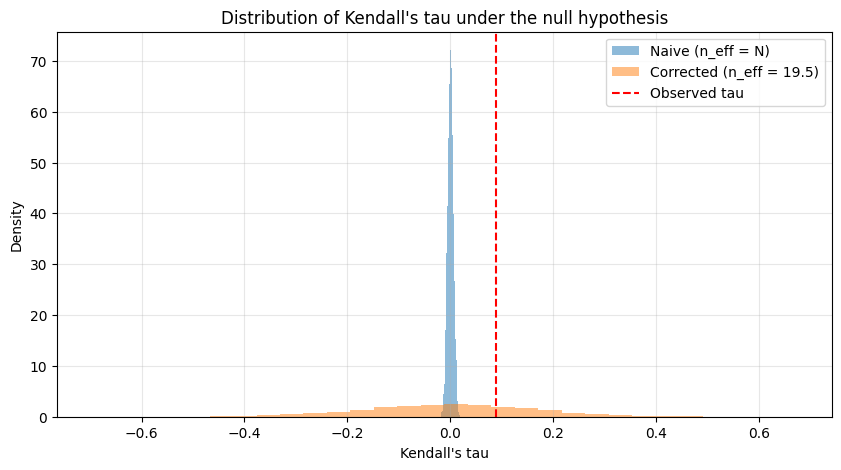

In [5]:
# Correction Plot: visual comparison between tau distributions at h0 with n=14232 and with n_eff = 20 (non-overlapping windows) — the latter is much wider, showing how the naive p-value is misleadingly small.
# Code below is for illustration, not a formal test (it doesn't preserve the time series structure, but it shows how the p-value changes when we reduce n_eff).
from scipy.stats import kendalltau  
def simulate_kendall_tau(n_samples, n_eff):
    """Simulate Kendall's tau under the null with n_eff independent points."""
    # Simulate n_eff independent pairs of random variables
    x = np.random.rand(int(n_eff))
    y = np.random.rand(int(n_eff))
    # Compute Kendall's tau on the full n_samples (with duplicates)
    x_full = np.repeat(x, int(n_samples / n_eff))
    y_full = np.repeat(y, int(n_samples / n_eff))
    tau, _ = kendalltau(x_full, y_full)
    return tau

n_simulations = 10000
taus_naive = [simulate_kendall_tau(N, N) for _ in range(n_simulations)]
taus_corrected = [simulate_kendall_tau(N, n_eff_use) for _ in range(n_simulations)]
plt.figure(figsize=(10, 5))
plt.hist(taus_naive, bins=30, alpha=0.5, label='Naive (n_eff = N)', density=True)
plt.hist(taus_corrected, bins=30, alpha=0.5, label=f'Corrected (n_eff = {n_eff_use:.1f})', density=True)
plt.axvline(tau, color='red', linestyle='--', label='Observed tau')
plt.title("Distribution of Kendall's tau under the null hypothesis")
plt.xlabel("Kendall's tau")
plt.ylabel("Density")
plt.legend()
plt.show()

## **3. Isolation Forest: a complementary question**

The classical EWS ask *"is there a slow monotonic drift toward a threshold?"* — a question about **trend** (answer: no detectable signal). The Isolation Forest asks a different question: *"which individual moments are unusual relative to typical AMOC behaviour?"* — a question about **events**.

> **The intuition.** Picture drawing random lines through a room of people: someone in the dense crowd needs many cuts to be isolated; someone standing alone in a corner is isolated in one or two. Anomalies are *easy to isolate*. The algorithm builds many random-splitting trees, measures the average depth at which each point gets isolated, and converts it to an anomaly score — shallow isolation = anomaly (Liu, Ting & Zhou, 2008).

> **Why it complements EWS.** The two are like a seismograph and a thermometer — different measurements of the same Earth. A system can have *no trend* (flat EWS) and still contain *discrete anomalous events*. That combination, if found, is the key result of §6.3.4: the AMOC shows no monotonic approach to a bifurcation, yet contains distinct anomalous episodes that trend indicators cannot, by construction, capture. Also, it does not assume any shape for the data, no normal distribution, no trend. It's unsupervised and non-parametric.

> **Input:** PC1(t) and PC2(t) jointly — 97.86% of the vertical structure, so the detector sees both intensity and redistribution, while staying interpretable and directly comparable to the EWS (same input, two methods, two questions).

> **Method choice — contamination.** This is the one imposed parameter: the fraction of days flagged as anomalous. There is no "true" value; it is a stated convention. We adopt **5%** (common for environmental anomalies, selective enough to surface only distinctive events) and verify the main events survive changes to it — the same anti-cherry-picking discipline applied to the EWS. A fixed `random_state` ensures reproducibility.

In [6]:
from sklearn.ensemble import IsolationForest

# Build the 2-D feature matrix: each day = (PC1, PC2)
# This is because scikit-learn's IsolationForest expects a 2-D array of shape (n_samples, n_features). Here, each "sample" is a day, and the "features" are the PC1 and PC2 scores for that day. By stacking them together, we create a 2-D array where each row corresponds to a day and has two columns: [PC1_score, PC2_score].
X_if = np.column_stack([pc1, pc2])   # shape (14596, 2)
display(X_if[:5])  # quick look at the first 5 rows
print(f"Isolation Forest input: {X_if.shape}  # (days, [PC1, PC2])")

# --- Fit --- (creates the object without training it yet)
contamination = 0.05 # expected % fraction of anomalies (tune as needed)
iso = IsolationForest(
    contamination=contamination,
    random_state=42,           # reproducibility — same events on re-run
    n_estimators=200,          # number of trees; 200 is stable for 2-D (good compromise, more is more accurate but slower)
)
iso.fit(X_if) # method call to train the model on the data

# scores matrix for each day: higher = more normal in sklearn's convention, so we negate
# anomaly score: higher = more normal in sklearn's convention, so we negate
# to get an intuitive "anomaly score" where higher = more anomalous
raw_score = iso.decision_function(X_if)      # high = normal
print(f"Raw anomaly scores (higher = more normal): {raw_score[:5]} ...")
anomaly_score = -raw_score                   # high = anomalous (nummpy applies negation elementwise)
is_anomaly = iso.predict(X_if) == -1         # boolean flag
print(f"Anomaly flags (True = anomalous): {is_anomaly[:5]} ...")

n_flagged = is_anomaly.sum()
print(f"Flagged anomalies: {n_flagged:,} days ({100*n_flagged/len(X_if):.1f}%)")

# --- Build a Series for plotting/inspection ---
anom_series = pd.Series(anomaly_score, index=times, name='anomaly_score')
flag_series = pd.Series(is_anomaly, index=times)

# --- Which calendar years hold the most anomalies? ---
anom_by_year = flag_series.groupby(flag_series.index.year).sum()
print("\nAnomalous days per year (top 8):")
print(anom_by_year.sort_values(ascending=False).head(8).to_string())

array([[-71.84912053, -19.43309968],
       [-48.94069392, -17.69480467],
       [-22.14632175, -17.83895493],
       [-13.84127954, -15.77881186],
       [-44.57713745, -11.69295117]])

Isolation Forest input: (14596, 2)  # (days, [PC1, PC2])
Raw anomaly scores (higher = more normal): [0.09356331 0.13955149 0.15960829 0.17239231 0.15636277] ...
Anomaly flags (True = anomalous): [False False False False False] ...
Flagged anomalies: 730 days (5.0%)

Anomalous days per year (top 8):
2010    121
2018     66
2005     59
2012     50
2013     50
2023     45
2006     42
2009     37


**Reading the anomaly distribution: convergence across methods.**

| Period | Anomalous days | Cross-method status |
|---|---|---|
| 2009–2010 | 158 (37 + 121) | **Dominant** — seen in NB01 Hovmöller, NB03 PC1 dip, NB04 series minimum |
| 2012–2013 | 100 (50 + 50) | Matches the NB04 rolling-variance peak |
| 2018 | 66 | Matches the second NB04 variance peak (and the NB03 +10.73 rebound) |
| 2005 | 59 | Unanticipated — see note |

> **The strong confirmation.** The Isolation Forest knows nothing of PCA, EWS, or the physics — it sees only the geometry of points in the PC1–PC2 plane. Independently, it lights up **2009–2010** as the dominant anomaly, the same event identified by three other lenses. When methods that share no assumptions point to the same moment, that moment is real, not a method artefact. 2009–2010 is the most robust physical fact of Part I.

> **The enrichment.** 2012–2013 and 2018 — the two rolling-variance peaks from NB04 — are independently flagged. High variance means the AMOC was oscillating widely, and wide oscillations push days far from the dense central cloud, making them easy to isolate. The trend method (variance) and the event method (Isolation Forest) agree on *which* periods are turbulent, despite asking different questions.

> **An honest note on 2005.** The 2005 flag (59 days) was not anticipated. Two readings, presented without forcing a choice: either 2005 was genuinely unusual in vertical structure (plausible — early RAPID years can show distinctive features), or it is an **edge effect**. Unlike the EWS (whose detrending and rolling windows consume the record's edges), the Isolation Forest sees every day including the first; if the array's earliest period differs slightly, those days are flagged. To be verified rather than explained away.

> **Event dating.** 2009 carries 37 days, 2010 carries 121 — the event's core is in early 2010, consistent with the known AMOC minimum over winter 2009–2010. The algorithm dates the event correctly.

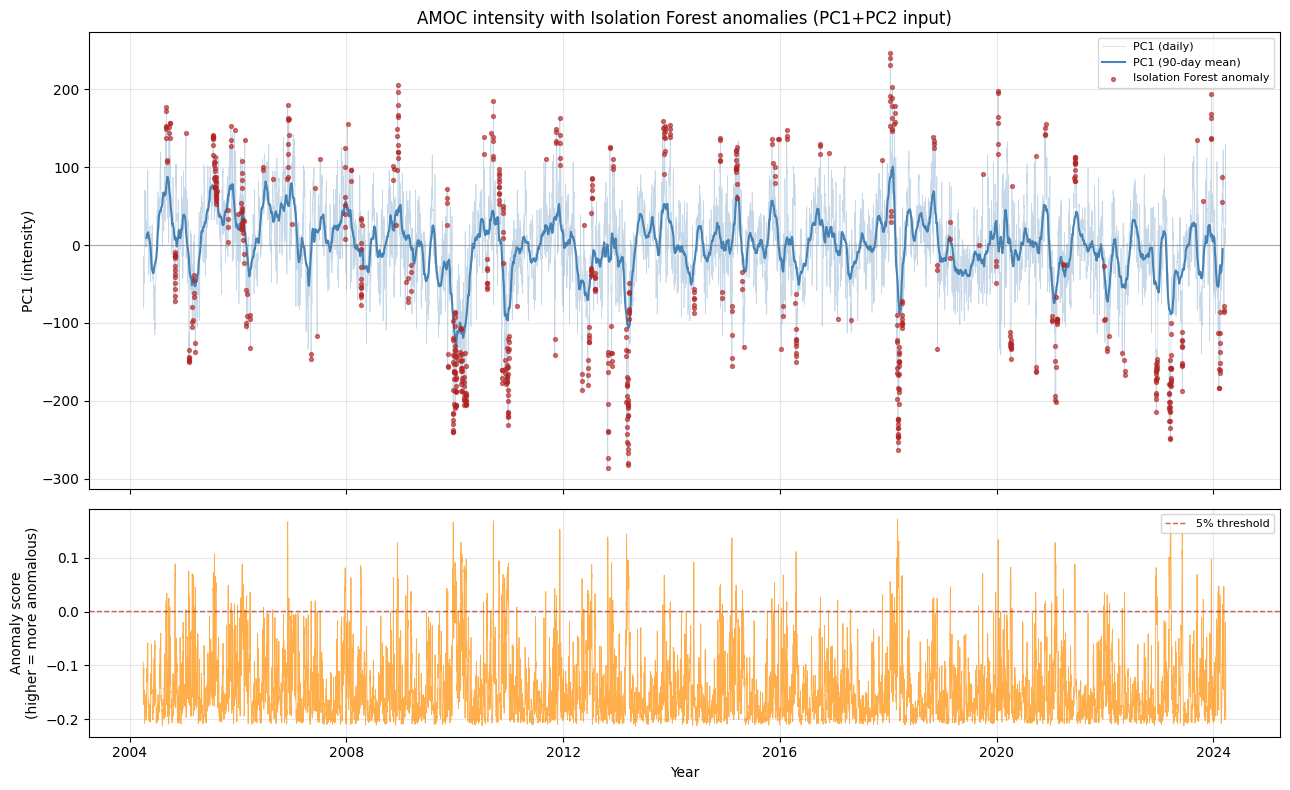

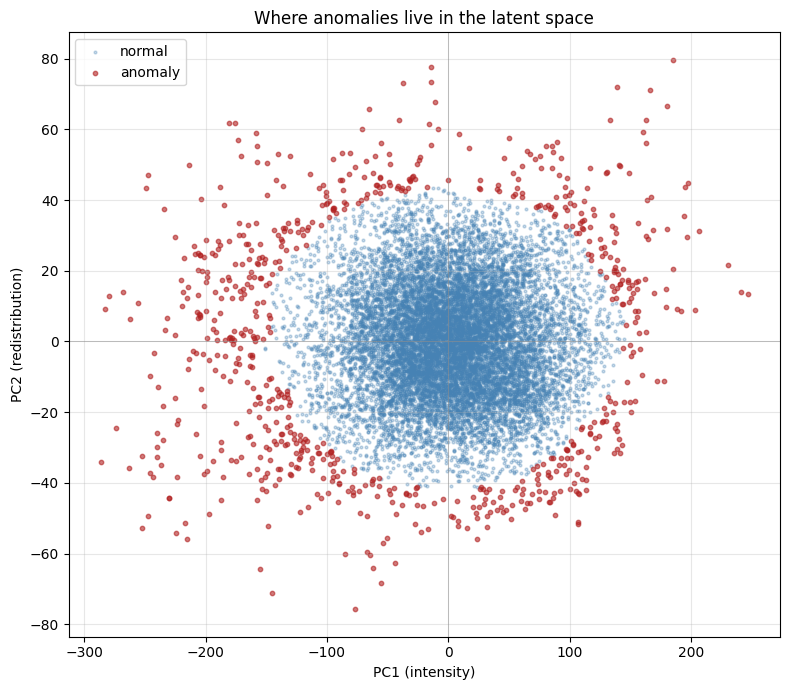

In [7]:
# Plotting AMOC intensity (PC1) with Isolation Forest anomalies and the anomaly score over time.

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

# --- Top: PC1(t) with anomalous days marked ---
ax1.plot(times, pc1, color='steelblue', alpha=0.3, linewidth=0.5,
         label='PC1 (daily)')
ax1.plot(times, pd.Series(pc1, index=times).rolling(90, center=True).mean(),
         color='steelblue', linewidth=1.5, label='PC1 (90-day mean)')
# overlay anomalies as red dots
ax1.scatter(times[is_anomaly], pc1[is_anomaly], color='firebrick', s=8,
            alpha=0.6, zorder=5, label='Isolation Forest anomaly')
ax1.axhline(0, color='gray', linewidth=0.8, alpha=0.6)
ax1.set_ylabel('PC1 (intensity)')
ax1.set_title('AMOC intensity with Isolation Forest anomalies (PC1+PC2 input)')
ax1.legend(loc='upper right', fontsize=8)

# --- Bottom: anomaly score over time ---
ax2.plot(times, anomaly_score, color='darkorange', linewidth=0.6, alpha=0.7)
# threshold line: the score above which days are flagged
threshold = anomaly_score[is_anomaly].min()
ax2.axhline(threshold, color='firebrick', linestyle='--', linewidth=1,
            alpha=0.7, label=f'5% threshold')
ax2.set_ylabel('Anomaly score\n(higher = more anomalous)')
ax2.set_xlabel('Year')
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

# Plotting the anomaly score distribution and the threshold for flagging anomalies.
# --- Where in the PC1-PC2 plane do anomalies sit? ---
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(pc1[~is_anomaly], pc2[~is_anomaly], s=4, alpha=0.3,
           color='steelblue', label='normal')
ax.scatter(pc1[is_anomaly], pc2[is_anomaly], s=10, alpha=0.6,
           color='firebrick', label='anomaly')
ax.axhline(0, color='gray', linewidth=0.6, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.6, alpha=0.5)
ax.set_xlabel('PC1 (intensity)')
ax.set_ylabel('PC2 (redistribution)')
ax.set_title('Where anomalies live in the latent space')
ax.legend()
plt.tight_layout()
plt.show()

**Reading the two figures.**

> **Anomalies sit on the extremes (top).** Red points cluster where PC1 departs from zero in *both* directions — the deep troughs (the 2010 wall at −200/−250, 2012–2013) and the high peaks (2018 above +200). The anomaly-score panel shows *no trend over time*: anomalies are spread across the whole record, not concentrated toward the end. This independently confirms the EWS null — no drift — from a different method.

> **The latent space is a target, not a uniform field (bottom).** A dense central cloud of normal days surrounds the origin; a sparse red ring of anomalies occupies the perimeter. Three readings:
> - *Geometric:* the Isolation Forest isolates what lies far from density — the "person alone in the corner", made visible. Anomalies *are* the perimeter.
> - *Physical:* the ring is roughly symmetric. A day is anomalous because it is *extreme in any direction* — very strong, very weak, or with unusual vertical redistribution (high/low PC2) — **not** because the AMOC is weak. Anomaly is distance from normality, not weakness. This dismantles the intuitive "anomalous = collapse signal".
> - *For Part II:* this is a **relief map** of the space Condition 3 must make navigable. The latent space has a central plain where the AMOC lives most of the time and a mountainous rim of rare states; the anomaly score is the altitude. A person navigating from centre to rim should *feel* the shift from familiar to extreme — and the topography of the latent space is now measured, not invented.

In [8]:
# How much do the two methods agree on WHICH periods are notable?
# EWS notion of "notable" = high local variance. IF notion = flagged anomaly.
# We compute, for each anomalous day, the local rolling variance percentile,
# to see whether IF anomalies preferentially sit in high-variance periods.

local_var = residual.rolling(var_win, center=True).var()
# percentile rank of local variance on each day (0-1)
var_pct = local_var.rank(pct=True)

# variance percentile on anomalous vs normal days
anom_var_pct = var_pct[is_anomaly].dropna()
norm_var_pct = var_pct[~is_anomaly].dropna()

print("Local variance percentile (where each method's 'notable' days sit):")
print(f"  IF-anomalous days : median variance percentile = {anom_var_pct.median():.2f}")
print(f"  normal days       : median variance percentile = {norm_var_pct.median():.2f}")

# What fraction of IF anomalies fall in the top-quartile-variance periods?
in_high_var = (var_pct[is_anomaly] > 0.75).mean()
print(f"\nFraction of IF anomalies in top-25%-variance periods: {in_high_var:.1%}")
print(f"(If methods were identical → ~100%. If independent → ~25%.)")

Local variance percentile (where each method's 'notable' days sit):
  IF-anomalous days : median variance percentile = 0.73
  normal days       : median variance percentile = 0.49

Fraction of IF anomalies in top-25%-variance periods: 41.4%
(If methods were identical → ~100%. If independent → ~25%.)


## **4. EWS vs Isolation Forest: complementary, quantified**

The two methods are not in competition and do not validate each other in the naive sense. They answer *different questions*, so the comparison asks not "which is right?" but "what does each see that the other is blind to?".

| | Classical EWS | Isolation Forest |
|---|---|---|
| **Question** | Is there a slow monotonic drift toward a threshold? | Which individual moments are unusual? |
| **Object** | Trend (gradual evolution) | Events (discrete points) |
| **Sees** | Critical-slowing-down signatures | Extremes in any direction |
| **Blind to** | Isolated extremes in calm periods | Slow drift with no single extreme day |
| **Result here** | No significant trend (p = 0.63, 0.60) | 2009–2010 dominant; 2012–13, 2018, 2005 flagged |
| **Assumptions** | CSD theory; detrending; window choice | None on data shape; non-parametric |

> **The overlap is 41.4%.** Of the Isolation Forest anomalies, 41% fall in top-quartile-variance periods (identical methods → ~100%; independent → ~25%). The two are **partially overlapping, not coincident**: they agree on turbulent events like 2009–2010, but ~60% of IF anomalies sit in normal-variance periods — *isolated extremes the rolling variance drowns in its window average*. A lone spike in a calm sea: variance misses it, Isolation Forest isolates it at once.

> **The percentile signature.** IF-anomalous days sit at a median 73rd percentile of local variance; normal days at the 49th. Anomalies *lean toward* turbulent periods (73 > 49, not chance) without *coinciding* with them — the quantitative fingerprint of complementarity.

> **Why this is the §6.3.4 result.** "I used two methods" becomes "I demonstrated numerically that the two are complementary, the 41% overlap placing them between redundancy and independence." The combined picture is richer than either alone: the AMOC shows **no monotonic approach to a bifurcation** (EWS), yet contains **discrete anomalous episodes** that trend indicators cannot capture (IF) — and those episodes converge, across four independent lenses, on 2009–2010.

## Summary & Next Steps

**Guiding question:** does the AMOC intensity record show signatures of approach to a bifurcation — via classical early warning signals, or via ML anomaly detection — and how robust are they? **Answer: no robust trend signature (rigorous null), but clear discrete anomalous events, the two findings being complementary, not contradictory.**

**What we did:**
1. Reloaded PC1(t) from NB03 (no recomputation), detrended with a 365-day moving mean, kept the residual
2. Computed rolling variance and rolling AR1 (730-day window) — the two classical EWS
3. Tested their trends with Kendall's τ, then **corrected for pseudo-replication** using the effective number of independent observations
4. Ran an Isolation Forest on PC1+PC2 (contamination 5%, 200 trees, seeded) for anomaly detection
5. Quantified the overlap between the two methods

**What we found:**

| Result | Value | Reading |
|---|---|---|
| Rolling variance trend | τ = +0.078, corrected p = 0.634 | No significant trend |
| Rolling AR1 trend | τ = +0.088, corrected p = 0.595 | No significant trend |
| AR1 level | ~0.93–0.96 | High from daily inertia, *not* tipping |
| Effective N | ~19.5 (not 14,232) | The pseudo-replication correction |
| IF dominant anomaly | 2009–2010 (158 days) | Converges with NB01, NB03 |
| IF secondary | 2012–13, 2018, 2005 | Variance peaks + one edge-effect candidate |
| Method overlap | 41.4% | Complementary, not coincident |

**Interpretation.** Over the RAPID record the classical EWS show no robust critical-slowing-down signature — and the naive significance (p ~ 10⁻⁴²) was an artefact of overlapping windows, corrected to non-significance once the ~19 independent windows are counted. This quantitatively supports the critics (Ben-Yami et al., 2023, 2024) that twenty years is too short for reliable AMOC EWS. The Isolation Forest, asking a different question, independently recovers 2009–2010 and the high-variance periods, and reveals the latent space as a target — a dense normal core ringed by extremes in all directions (anomaly = distance from normality, not weakness).

**The methodological contribution.** The pseudo-replication correction is the original methodological core of Part I: a worked demonstration that an apparently overwhelming EWS signal dissolves under an honest count of independent observations. This is more valuable to a thesis on *the limits of knowing the AMOC* than a fragile positive would have been.

**Next steps (notebook 05 — autoencoder):**
- Train an autoencoder on the 307-level vertical profiles; benchmark reconstruction against the PCA's **97.86%** (2 modes). A 2-latent autoencoder must beat this to justify its non-linearity
- Use reconstruction error as a second, non-linear anomaly score — compare against this Isolation Forest baseline
- The latent space (PCA now, autoencoder next) is the substrate for Part II's experiential representation

**Before notebook 05: a writing checkpoint.** This notebook produced the material for §6.3.1–6.3.4 (EWS formulation, results, Isolation Forest, comparison) and a substantial §10.1.2 (anomaly/EWS findings), plus a strong entry for the limitations chapter (daily AR1 saturation; record length).